# Subscription-Based-Customer-Retention-System

## Life cycle of Machine learning Project

* Understanding the Problem Statement
* Data Collection
* Data Checks to perform
* Exploratory data analysis
* Data Pre-Processing
* Model Training
* Choose best model

## 1 Problem statement

* This project understands how the customer attrition is happening by the variables such as Streaming movies, monthly charges, contract, paperlessbilling, payment method etc.

## 2 Data Collection

* Dataset Source - https://www.kaggle.com/datasets/blastchar/telco-customer-churn
* The data consists of 21 columns and 7044 rows.

## 2.1 Import Data and Required Packages

* Importing math, numpy, pandas, matplotlib, Seaborn and warnings library.    



In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.shape

(7043, 21)

## 3 Data checks to perform

* Check Missing values
* Check Duplicates
* Check data type
* Check the number of unique values of each column
* Check statistics of data set
* Explore data



## 3.1 Check Missing values

In [8]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## 3.2 Check Duplicates

In [9]:
df.duplicated().sum()

np.int64(0)

## 3.3 Check data types

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 3.4 Check the number of unique values of each column

In [11]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

## 3.5 Check statistics of dataset

In [12]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 3.6 Exploring data

In [13]:
a1 = df.loc[ : ,'SeniorCitizen'].unique()
value_counts = df['SeniorCitizen'].value_counts(normalize=True) * 100 # Count occurrences of each unique value
print("SeniorCitizen Column --------------------------------------------------------------------------------------------------------------------------------->")
print(f"Percentage of 0: {value_counts[0]:.2f}%") # Print percentage of 0s and 1s
print(f"Percentage of 1: {value_counts[1]:.2f}%")



a2 = df.loc[ : ,"Partner"].unique()
value_counts = df['Partner'].value_counts(normalize=True) * 100
print("Partner Column -------------------------------------------------------------------------------------------------------------------------------------->")
print(f"Percentage of Yes: {value_counts['Yes']:.2f}%")
print(f"Percentage of No: {value_counts['No']:.2f}%")



a3 = df.loc[ : ,"Dependents"].unique()
value_counts = df['Dependents'].value_counts(normalize=True) * 100
print("Dependents Column ---------------------------------------------------------------------------------------------------------------------------------->")
print(f"Percentage of Yes: {value_counts['Yes']:.2f}%")
print(f"Percentage of No: {value_counts['No']:.2f}%")



df["tenure"] = pd.to_numeric(df["tenure"], errors='coerce')
df.fillna(df.select_dtypes(include=[np.number]).mean(),inplace=True)



a4 = df.loc[ : ,"PhoneService"].unique()
value_counts = df['PhoneService'].value_counts(normalize=True) * 100
print("PhoneService Column ------------------------------------------------------------------------------------------------------------------------------->")
print(f"Percentage of Yes: {value_counts['Yes']:.2f}%")
print(f"Percentage of No: {value_counts['No']:.2f}%")



a5 = df.loc[ : ,"MultipleLines"].unique()
value_counts = df['MultipleLines'].value_counts(normalize=True) * 100
print("MultipleLines Column ----------------------------------------------------------------------------------------------------------------------------->")
print(f"Percentage of 'No Phone Service': {value_counts['No phone service']:.2f}%")
print(f"Percentage of Yes: {value_counts['Yes']:.2f}%")
print(f"Percentage of No: {value_counts['No']:.2f}%")



a6 = df.loc[ : ,"InternetService"].unique()
value_counts = df['InternetService'].value_counts(normalize=True) * 100
print("InternetService Column -------------------------------------------------------------------------------------------------------------------------->")
print(f"Percentage of 'DSL': {value_counts['DSL']:.2f}%")
print(f"Percentage of 'Fiber optic': {value_counts['Fiber optic']:.2f}%")
print(f"Percentage of No: {value_counts['No']:.2f}%")



a7 = df.loc[ : ,"OnlineSecurity"].unique()
value_counts = df['OnlineSecurity'].value_counts(normalize=True) * 100
print("OnlineSecurity Column -------------------------------------------------------------------------------------------------------------------------->")
print(f"Percentage of 'No internet service': {value_counts['No internet service']:.2f}%")
print(f"Percentage of 'Yes': {value_counts['Yes']:.2f}%")
print(f"Percentage of No: {value_counts['No']:.2f}%")



a8 = df.loc[ : ,"OnlineBackup"].unique()
value_counts = df['OnlineBackup'].value_counts(normalize=True) * 100
print("OnlineBackup Column ---------------------------------------------------------------------------------------------------------------------------->")
print(f"Percentage of 'No internet service': {value_counts['No internet service']:.2f}%")
print(f"Percentage of 'Yes': {value_counts['Yes']:.2f}%")
print(f"Percentage of No: {value_counts['No']:.2f}%")



a9 = df.loc[ : ,"DeviceProtection"].unique()
value_counts = df['DeviceProtection'].value_counts(normalize=True) * 100     # print value_counts in both cases to prove that its just a coincidence
print("DeviceProtection Column ----------------------------------------------------------------------------------------------------------------------->")
print(f"Percentage of 'No internet service': {value_counts['No internet service']:.2f}%")
print(f"Percentage of 'Yes': {value_counts['Yes']:.2f}%")
print(f"Percentage of No: {value_counts['No']:.2f}%")



a10 = df.loc[ : ,"TechSupport"].unique()
value_counts = df['TechSupport'].value_counts(normalize=True) * 100
print("TechSupport Column ---------------------------------------------------------------------------------------------------------------------------->")
print(f"Percentage of 'No internet service': {value_counts['No internet service']:.2f}%")
print(f"Percentage of 'Yes': {value_counts['Yes']:.2f}%")
print(f"Percentage of No: {value_counts['No']:.2f}%")



a11 = df.loc[ : ,"StreamingTV"].unique()
value_counts = df['StreamingTV'].value_counts(normalize=True) * 100
print("StreamingTV Column ---------------------------------------------------------------------------------------------------------------------------->")
print(f"Percentage of 'No internet service': {value_counts['No internet service']:.2f}%")
print(f"Percentage of 'Yes': {value_counts['Yes']:.2f}%")
print(f"Percentage of No: {value_counts['No']:.2f}%")



a12 = df.loc[ : ,"StreamingMovies"].unique()
value_counts = df['StreamingMovies'].value_counts(normalize=True) * 100
print("StreamingMovies Column ------------------------------------------------------------------------------------------------------------------------>")
print(f"Percentage of 'No internet service': {value_counts['No internet service']:.2f}%")
print(f"Percentage of 'Yes': {value_counts['Yes']:.2f}%")
print(f"Percentage of No: {value_counts['No']:.2f}%")



a13 = df.loc[ : ,"Contract"].unique()
value_counts = df['Contract'].value_counts(normalize=True) * 100
print("Contract Column ------------------------------------------------------------------------------------------------------------------------------->")
print(f"Percentage of 'Month-to-month': {value_counts['Month-to-month']:.2f}%")
print(f"Percentage of 'One year': {value_counts['One year']:.2f}%")
print(f"Percentage of 'Two year': {value_counts['Two year']:.2f}%")



a14 = df.loc[ : ,"PaperlessBilling"].unique()
value_counts = df['PaperlessBilling'].value_counts(normalize=True) * 100
print("PaperlessBilling Column ---------------------------------------------------------------------------------------------------------------------->")
print(f"Percentage of 'Yes': {value_counts['Yes']:.2f}%")
print(f"Percentage of No: {value_counts['No']:.2f}%")



a15 = df.loc[ : ,"PaymentMethod"].unique()
print(a15)
value_counts = df['PaymentMethod'].value_counts(normalize=True) * 100
print("PaymentMethod Column ------------------------------------------------------------------------------------------------------------------------->")
print(f"Percentage of 'Electronic check': {value_counts['Electronic check']:.2f}%")
print(f"Percentage of 'Mailed check': {value_counts['Mailed check']:.2f}%")
print(f"Percentage of 'Bank transfer (automatic)': {value_counts['Bank transfer (automatic)']:.2f}%")
print(f"Percentage of 'Credit card (automatic)': {value_counts['Credit card (automatic)']:.2f}%")



df["MonthlyCharges"] = pd.to_numeric(df["MonthlyCharges"], errors='coerce')
df.fillna(df.select_dtypes(include=[np.number]).mean(),inplace=True)



df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
df.fillna(df.select_dtypes(include=[np.number]).mean(),inplace=True)



a15 = df.loc[ : ,"Churn"].unique()
value_counts = df['Churn'].value_counts(normalize=True) * 100
print("Churn Column -------------------------------------------------------------------------------------------------------------------------------->")
print(f"Percentage of 'Yes': {value_counts['Yes']:.2f}%")
print(f"Percentage of No: {value_counts['No']:.2f}%")

SeniorCitizen Column --------------------------------------------------------------------------------------------------------------------------------->
Percentage of 0: 83.79%
Percentage of 1: 16.21%
Partner Column -------------------------------------------------------------------------------------------------------------------------------------->
Percentage of Yes: 48.30%
Percentage of No: 51.70%
Dependents Column ---------------------------------------------------------------------------------------------------------------------------------->
Percentage of Yes: 29.96%
Percentage of No: 70.04%
PhoneService Column ------------------------------------------------------------------------------------------------------------------------------->
Percentage of Yes: 90.32%
Percentage of No: 9.68%
MultipleLines Column ----------------------------------------------------------------------------------------------------------------------------->
Percentage of 'No Phone Service': 9.68%
Percentage

## 3.7 Dropping unnecessary columns 

In [14]:
df.drop(["customerID"],axis=1,inplace=True)
df.drop(["gender"],axis=1,inplace=True)
# The parameter inplace=True modifies the DataFrame df directly instead of creating a new copy.
# No need to assign df = df.drop(...), as the DataFrame is updated in place.

df.shape

(7043, 19)

## 3.8 Median values of Tenure, MonthlyCharges and TotalCharges Column

In [15]:
columns_to_check = ["tenure", "MonthlyCharges", "TotalCharges"]  # Select columns
medians = df[columns_to_check].median()
print("Median Values:")
print("---------------------------------------------------------------------------------------------------------------------------------------------------")
print(medians)

Median Values:
---------------------------------------------------------------------------------------------------------------------------------------------------
tenure              29.00
MonthlyCharges      70.35
TotalCharges      1400.55
dtype: float64


## 4 Data Visualization

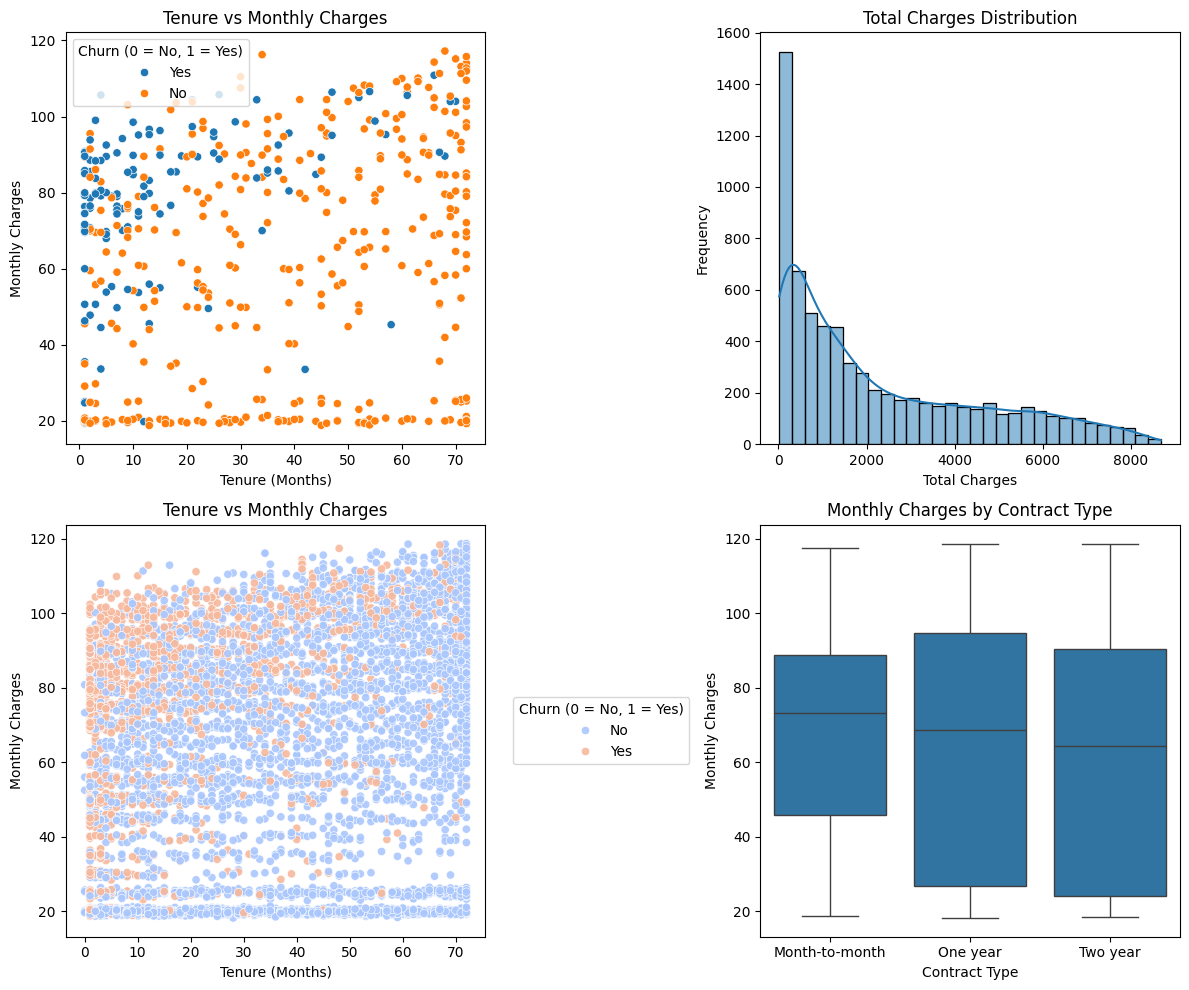

In [16]:
# Create the 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# First plot: Scatter plot (top-left)
df_sample = df.sample(500, random_state=42)  # Sample for better visualization
sns.scatterplot(x=df_sample["tenure"], y=df_sample["MonthlyCharges"], hue=df_sample["Churn"], ax=axes[0, 0])
axes[0, 0].set_title("Tenure vs Monthly Charges")
axes[0, 0].set_xlabel("Tenure (Months)")
axes[0, 0].set_ylabel("Monthly Charges")
axes[0, 0].legend(title="Churn (0 = No, 1 = Yes)", loc="best")

# Second plot: Histogram (top-right)
sns.histplot(df["TotalCharges"], kde=True, bins=30, ax=axes[0, 1])
axes[0, 1].set_title("Total Charges Distribution")
axes[0, 1].set_xlabel("Total Charges")
axes[0, 1].set_ylabel("Frequency")

# Third plot: Enhanced Scatter plot (bottom-left) - Modified
sns.scatterplot(
    data=df, x="tenure", y="MonthlyCharges", hue="Churn", palette="coolwarm", alpha=0.9, ax=axes[1, 0]
)
axes[1, 0].set_title("Tenure vs Monthly Charges")
axes[1, 0].set_xlabel("Tenure (Months)")
axes[1, 0].set_ylabel("Monthly Charges")
# Move legend outside the plot area to right center
axes[1, 0].legend(title="Churn (0 = No, 1 = Yes)", bbox_to_anchor=(1.05, 0.5), loc='center left')

# Fourth plot: Box plot (bottom-right)
sns.boxplot(x=df["Contract"], y=df["MonthlyCharges"], ax=axes[1, 1])
axes[1, 1].set_title("Monthly Charges by Contract Type")
axes[1, 1].set_xlabel("Contract Type")
axes[1, 1].set_ylabel("Monthly Charges")

plt.tight_layout()
plt.show()